# 🌍 GbeTo : Traducteur Éwé ↔ Français — Notebook Principal

**Auteur** : Kodjo Jean DEGBEVI  
**Modèle** : `facebook/nllb-200-distilled-600M` (fine-tuning)  
**Données** : AfroLingu-MT (ACL 2024) + MAFAND (NAACL 2022)  
**Repo** : [github.com/kjd-dktech/GbeTo_ewe-fr](https://github.com/kjd-dktech/GbeTo_ewe-fr)

---

## Structure du notebook

| Section | Contenu |
|---------|----------|
| **0** | Configuration de l'environnement Colab |
| **1** | Pipeline de données |
| **2** | Analyse exploratoire (EDA) |
| **3** | Entraînement |
| **4** | Évaluation et résultats |
| **5** | Error analysis |
| **6** | Démonstration interactive |

---
## Section 0 — Configuration de l'environnement

In [2]:
# ── 0.1 Vérification du GPU ──────────────────────────────────────────────────
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU : {gpu_name}")
    print(f"   VRAM : {vram_gb:.1f} GB")
else:
    print("⚠️  Aucun GPU détecté — activer le GPU dans Exécution → Modifier le type d'exécution")

✅ GPU : Tesla T4
   VRAM : 15.6 GB


In [3]:
# ── 0.2 Montage Google Drive ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/General/Projet_NLP/GbeTo'
print(f"Chemin du projet : {PROJECT_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Chemin du projet : /content/drive/MyDrive/General/Projet_NLP/GbeTo


In [4]:
# ── 0.3 Positionnement dans le dossier projet ────────────────────────────────
import os
os.chdir(PROJECT_PATH)

import subprocess
result = subprocess.run(['pwd'], capture_output=True, text=True)
print(f"Répertoire courant : {result.stdout.strip()}")

# Cache HuggingFace persistant sur Drive
HF_CACHE = '/content/drive/MyDrive/General/Projet_NLP/GbeTo/hf_cache'
os.makedirs(HF_CACHE, exist_ok=True)
os.environ['HF_HOME']             = HF_CACHE
os.environ['TRANSFORMERS_CACHE']  = HF_CACHE
os.environ['HF_DATASETS_CACHE']   = HF_CACHE

print(f"Cache HuggingFace → {HF_CACHE}")

Répertoire courant : /content/drive/.shortcut-targets-by-id/1geGHmVctXtC1kx_DccJ7FcAoTH6dOb7v/GbeTo
Cache HuggingFace → /content/drive/MyDrive/General/Projet_NLP/GbeTo/hf_cache


In [5]:
# ── 0.4 Installation des dépendances ────────────────────────────────────────
!pip install -r requirements.txt -q
print("✅ Dépendances installées.")

✅ Dépendances installées.


In [6]:
# ── 0.5 Authentification — HuggingFace et W&B ───────────────────────────────
#
from google.colab import userdata
import os

# HuggingFace (requis pour AfroLingu-MT gated)
HF_TOKEN_READ = userdata.get('HF_TOKEN_READ')
os.environ['HF_TOKEN_READ'] = HF_TOKEN_READ

from huggingface_hub import login
login(token=HF_TOKEN_READ, add_to_git_credential=False)
print("✅ HuggingFace : authentifié.")

# Weights & Biases
WANDB_API_KEY = userdata.get('WANDB_API_KEY')
os.environ['WANDB_API_KEY'] = WANDB_API_KEY

import wandb
wandb.login(key=WANDB_API_KEY)
print("✅ W&B : authentifié.")

# Google Cloud Storage
# from google.colab import auth
# auth.authenticate_user()

# import google.auth
# credentials, project = google.auth.default()
# print(f"✅ GCS : authentifié (projet : {project})")

✅ HuggingFace : authentifié.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kjd-dktech (kjd-dktech-dktech-innovations) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B : authentifié.


In [7]:
# ── 0.6 Gestion de la continuité W&B après coupure Colab ────────────────────
#
# PREMIER LANCEMENT :
#   On laisse WANDB_RUN_ID = None
#   W&B créera une nouvelle run et affichera son ID dans les logs
#
# REPRISE APRÈS COUPURE :
#   On peut renseigner WANDB_RUN_ID avec l'ID de la run précédente ou
#   utiliser la cellule 3.2
#   Les nouvelles métriques s'ajouteront à la même run sur wandb.ai
#
WANDB_RUN_ID = None

if WANDB_RUN_ID:
    os.environ['WANDB_RUN_ID'] = WANDB_RUN_ID
    os.environ['WANDB_RESUME'] = 'must'
    print(f"✅ W&B : reprise de la run {WANDB_RUN_ID}")
else:
    os.environ.pop('WANDB_RUN_ID', None)
    os.environ.pop('WANDB_RESUME', None)
    print("ℹ️  W&B : nouvelle run (premier lancement)")

ℹ️  W&B : nouvelle run (premier lancement)


---
## Section 1 — Pipeline de données

In [ ]:
# ── 1.1 Téléchargement et fusion des datasets ────────────────────────────────
#
# Sources :
#   - UBC-NLP/AfroLingu-MT (ACL 2024) — gated, nécessite HF_TOKEN
#   - masakhane-io/lafand (NAACL 2022) — public
#
# Sorties : data/raw/merged_<split>.csv
#
!python -m src.data.download --output_dir data/raw

In [ ]:
# ── 1.2 Nettoyage et filtrage ────────────────────────────────────────────────
#
# Filtres appliqués dans l'ordre :
#   1. Normalisation Unicode NFC
#   2. Déduplication
#   3. Longueur : 3 ≤ mots ≤ 150
#   4. Ratio source/target : 0.2 ≤ ratio ≤ 5.0
#
!python -m src.data.filter --input_dir data/raw --output_dir data/processed

In [ ]:
# ── 1.3 Finalisation des splits ──────────────────────────────────────────────
#
# Shuffle reproductible avec seed=42
# Sorties : data/processed/train.csv, val.csv, test.csv
#
!python -m src.data.split --input_dir data/processed --output_dir data/processed

In [ ]:
# ── 1.4 Vérification des fichiers produits ───────────────────────────────────
import pandas as pd
from pathlib import Path

splits = {'train': 'data/processed/train.csv',
          'val':   'data/processed/val.csv',
          'test':  'data/processed/test.csv'}

print(f"{'Split':<8} {'Total':>8} {'ewe-fra':>10} {'fra-ewe':>10} {'afrolingu':>12} {'mafand':>10}")
print("-" * 62)

for name, path in splits.items():
    df = pd.read_csv(path)
    ewe_fra   = (df['direction'] == 'ewe-fra').sum()
    fra_ewe   = (df['direction'] == 'fra-ewe').sum()
    afrolingu = (df['origin'] == 'afrolingu').sum()
    mafand    = (df['origin'] == 'mafand').sum()
    print(f"{name:<8} {len(df):>8,} {ewe_fra:>10,} {fra_ewe:>10,} {afrolingu:>12,} {mafand:>10,}")

---
## Section 2 — Analyse exploratoire (EDA)

In [ ]:
# ── 2.0 Imports pour la visualisation ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.dpi':      120,
    'font.size':       11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

df_train = pd.read_csv('data/processed/train.csv')
df_val   = pd.read_csv('data/processed/val.csv')
df_test  = pd.read_csv('data/processed/test.csv')
print("Données chargées pour l'EDA.")

Données chargées pour l'EDA.


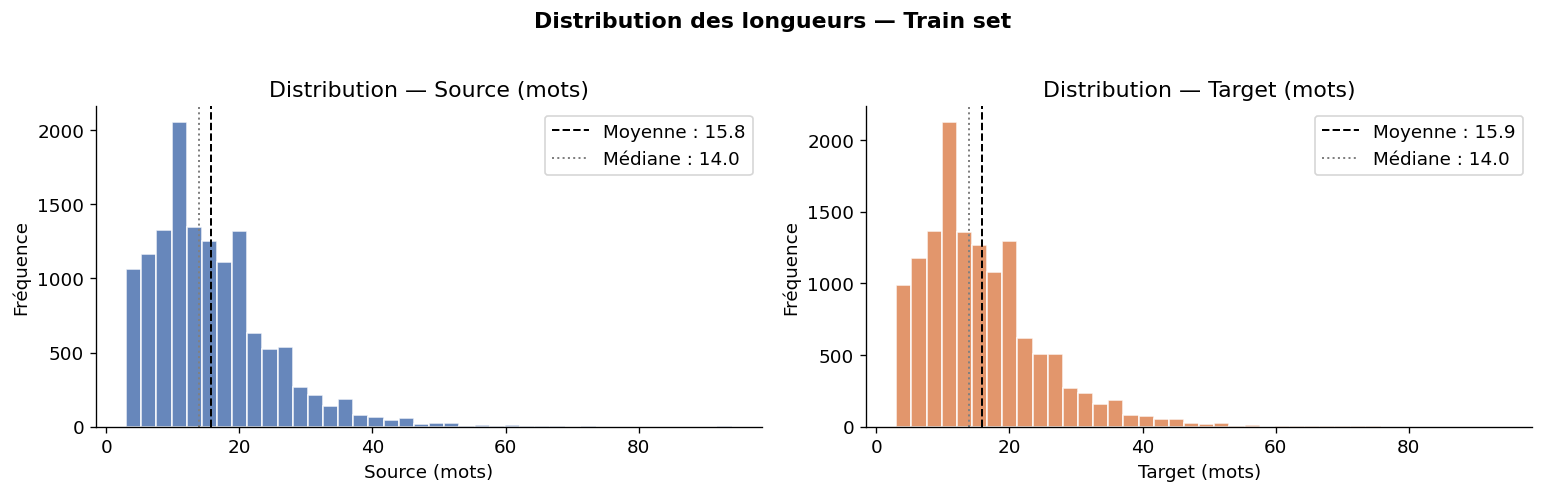


Source — moy: 15.8  méd: 14  max: 94
Target — moy: 15.9  méd: 14  max: 94


In [ ]:
# ── 2.1 Distribution des longueurs (en mots) ────────────────────────────────
df_train['src_len'] = df_train['source'].apply(lambda x: len(str(x).split()))
df_train['tgt_len'] = df_train['target'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label, color in zip(
    axes,
    ['src_len', 'tgt_len'],
    ['Source (mots)', 'Target (mots)'],
    ['#4C72B0', '#DD8452']
):
    ax.hist(df_train[col], bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(df_train[col].mean(),   color='black', linestyle='--',
               linewidth=1.2, label=f"Moyenne : {df_train[col].mean():.1f}")
    ax.axvline(df_train[col].median(), color='gray',  linestyle=':',
               linewidth=1.2, label=f"Médiane : {df_train[col].median():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel('Fréquence')
    ax.set_title(f'Distribution — {label}')
    ax.legend()

plt.suptitle('Distribution des longueurs — Train set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/eda_length_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nSource — moy: {df_train['src_len'].mean():.1f}  "
      f"méd: {df_train['src_len'].median():.0f}  "
      f"max: {df_train['src_len'].max()}")
print(f"Target — moy: {df_train['tgt_len'].mean():.1f}  "
      f"méd: {df_train['tgt_len'].median():.0f}  "
      f"max: {df_train['tgt_len'].max()}")

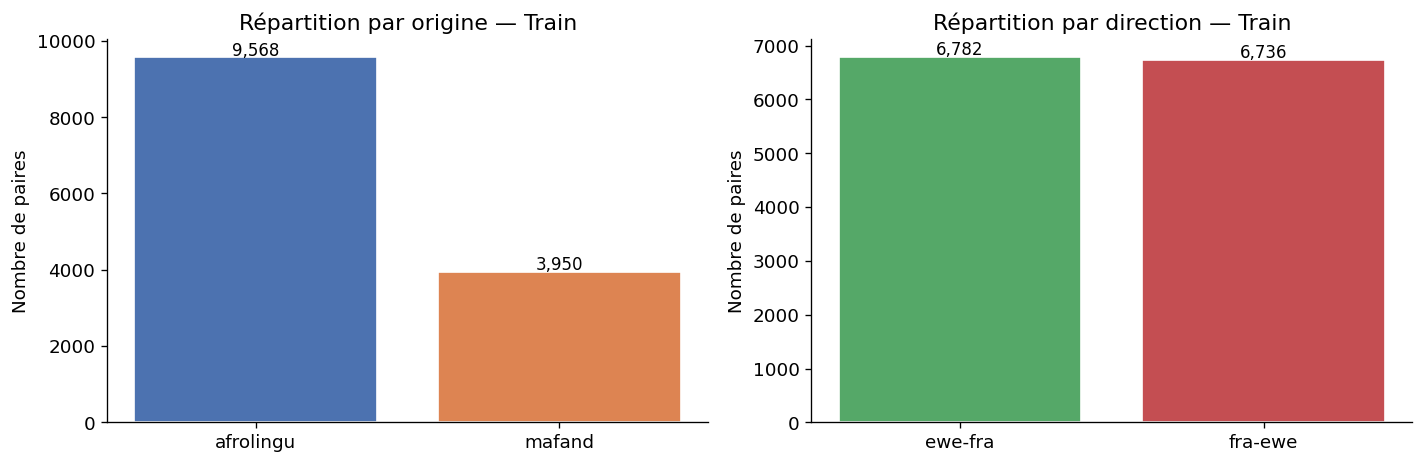

In [ ]:
# ── 2.2 Répartition par origine et direction ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Répartition par origine
origin_counts = df_train['origin'].value_counts()
axes[0].bar(origin_counts.index, origin_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Répartition par origine — Train')
axes[0].set_ylabel('Nombre de paires')
for i, v in enumerate(origin_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# Répartition par direction
dir_counts = df_train['direction'].value_counts()
axes[1].bar(dir_counts.index, dir_counts.values,
            color=['#55A868', '#C44E52'], edgecolor='white')
axes[1].set_title('Répartition par direction — Train')
axes[1].set_ylabel('Nombre de paires')
for i, v in enumerate(dir_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/eda_origin_direction.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 2.3 Exemples de paires du dataset ───────────────────────────────────────
print("=" * 70)
print("EXEMPLES DE PAIRES — AfroLingu-MT")
print("=" * 70)
sample_afro = df_train[df_train['origin'] == 'afrolingu'].sample(3, random_state=42)
for _, row in sample_afro.iterrows():
    print(f"\n  Direction : {row['direction']}")
    print(f"  Source    : {row['source']}")
    print(f"  Target    : {row['target']}")

print("\n" + "=" * 70)
print("EXEMPLES DE PAIRES — MAFAND")
print("=" * 70)
sample_mafand = df_train[df_train['origin'] == 'mafand'].sample(3, random_state=42)
for _, row in sample_mafand.iterrows():
    print(f"\n  Direction : {row['direction']}")
    print(f"  Source    : {row['source']}")
    print(f"  Target    : {row['target']}")

EXEMPLES DE PAIRES — AfroLingu-MT

  Direction : fra-ewe
  Source    : Il a ensuite saisi par le cou son amie qui avait cherché à s’interposer
  Target    : wobe edze hlo dzi na nyɔnua si dzi be yeagbe la

  Direction : fra-ewe
  Source    : La GIZ, Deutsche Gesellschaft für Internationale Zusammenarbeit, est une entreprise de la coopération internationale pour le développement durable qui opère sur tous les continents
  Target    : GIZ nye kadededɔ si kpɔa ŋgɔgbedede adodui gbɔ eye wole anyigbawo katã dzi

  Direction : ewe-fra
  Source    : nuka woa xɔse
  Target    : Qu'est ce qu'il faut croire,

EXEMPLES DE PAIRES — MAFAND

  Direction : ewe-fra
  Source    : Miese be Grandd P kple Eudoxie wɔ dekɔnulɔléle le guinée.
  Target    : Selon les dernières nouvelles, Grand P et Eudoxie Yao auraient fait leur mariage traditionnel en Guinée Conakry

  Direction : ewe-fra
  Source    : Le esi miele agbagba dzem be miatu xexea le nuƒoxlãmeo ɖɔɖɔɖo me la, edze be miatu xexe sime nublanuikpɔkpɔ

---
## Section 3 — Entraînement

**Comportement automatique :**
- Si `outputs/checkpoints/` contient des checkpoints → **reprise** depuis le dernier état
- Sinon → **nouveau départ**

**Suivi en temps réel :** [wandb.ai](https://wandb.ai) → projet `GbeTo_1`

In [ ]:
# ── 3.1 Lancement de l'entraînement ──────────────────────────────────────────
#
# Le script détecte automatiquement si c'est un nouveau départ ou une reprise.
# Les métriques sont envoyées en temps réel sur W&B.
#
!bash scripts/train.sh


  VÉRIFICATIONS PRÉALABLES
[OK]    Racine du projet détectée.
[OK]    Fichier .env chargé.
[OK]    Fichiers de données vérifiés.
[INFO]  Train : 13518 paires
[INFO]  Val   : 2919 paires
[OK]    GPU détecté : Tesla T4 (15.6GB VRAM)
[OK]    WANDB_API_KEY détecté.

  DÉTECTION DU MODE D'ENTRAÎNEMENT
[INFO]  Aucun checkpoint détecté → NOUVEAU DÉPART

  CONFIGURATION DE L'ENTRAÎNEMENT

[INFO]  Modèle           : facebook/nllb-200-distilled-600M
[INFO]  Learning rate    : 5e-5
[INFO]  Batch / device   : 4
[INFO]  Gradient accum   : 8  →  batch effectif : 32
[INFO]  Epochs max       : 10
[INFO]  Warmup steps     : 500
[INFO]  Warmup epochs    : 3 (pas de Drive avant cette epoch)
[INFO]  Keep local       : 3 meilleurs checkpoints locaux
[INFO]  Beam search      : 4
[INFO]  Seed             : 42
[INFO]  fp16             : oui
[INFO]  Tracking         : wandb
[INFO]  Checkpoints      : /content/checkpoints_local (local) → outputs/checkpoints (Drive, zip)


  LANCEMENT DE L'ENTRAÎNEMENT
[INFO]  

In [ ]:
# ── 3.2 Reprise de l'entrainement ──────
!bash scripts/resume.sh

Streaming output truncated to the last 5000 lines.
 18% 131/730 [03:24<17:22,  1.74s/it]
 18% 132/730 [03:26<16:26,  1.65s/it]
 18% 133/730 [03:29<20:09,  2.03s/it]
 18% 134/730 [03:30<17:42,  1.78s/it]
 18% 135/730 [03:32<18:38,  1.88s/it]
 19% 136/730 [03:34<17:30,  1.77s/it]
 19% 137/730 [03:38<24:10,  2.45s/it]
 19% 138/730 [03:39<21:35,  2.19s/it]
 19% 139/730 [03:41<19:42,  2.00s/it]
 19% 140/730 [03:42<17:29,  1.78s/it]
 19% 141/730 [03:43<15:51,  1.62s/it]
 19% 142/730 [03:45<15:18,  1.56s/it]
 20% 143/730 [03:46<15:13,  1.56s/it]
 20% 144/730 [03:48<15:30,  1.59s/it]
 20% 145/730 [03:49<13:15,  1.36s/it]
 20% 146/730 [03:50<12:43,  1.31s/it]
 20% 147/730 [03:51<12:03,  1.24s/it]
 20% 148/730 [03:52<11:17,  1.16s/it]
 20% 149/730 [03:54<13:44,  1.42s/it]
 21% 150/730 [03:56<15:20,  1.59s/it]
 21% 151/730 [03:57<14:09,  1.47s/it]
 21% 152/730 [03:58<12:45,  1.32s/it]
 21% 153/730 [03:59<11:07,  1.16s/it]
 21% 154/730 [04:01<14:31,  1.51s/it]
 21% 155/730 [04:05<20:43,  2.16s/it]

---
## Section 4 — Évaluation et résultats

In [ ]:
# ── 4.1 Chargement des métriques finales ────────────────────────────────────
import json
from pathlib import Path

metrics_path = Path('outputs/final_metrics.json')

if metrics_path.exists():
    with open(metrics_path) as f:
        metrics = json.load(f)

    print("=" * 50)
    print("MÉTRIQUES FINALES")
    print("=" * 50)
    print(f"  Modèle      : {metrics.get('model', 'N/A')}")
    print(f"  BLEU (val)  : {metrics.get('bleu_val', 0):.2f}")
    print(f"  chrF (val)  : {metrics.get('chrf_val', 0):.2f}")
    print(f"  Loss (val)  : {metrics.get('loss_val', 0):.4f}")
    print(f"  Train loss  : {metrics.get('train_loss', 0):.4f}")
    print()
    print("Hyperparamètres :")
    for k, v in metrics.get('hyperparameters', {}).items():
        print(f"  {k:<35} : {v}")
else:
    print("⚠️  outputs/final_metrics.json introuvable — lancer l'entraînement d'abord.")

MÉTRIQUES FINALES
  Modèle      : facebook/nllb-200-distilled-600M
  BLEU (val)  : 17.84
  chrF (val)  : 37.95
  Loss (val)  : 2.4285
  Train loss  : 5.3237

Hyperparamètres :
  learning_rate                       : 5e-05
  per_device_train_batch_size         : 4
  gradient_accumulation_steps         : 8
  effective_batch_size                : 32
  num_train_epochs                    : 10
  warmup_steps                        : 500
  weight_decay                        : 0.01
  max_length                          : 128
  num_beams                           : 4
  seed                                : 42


In [ ]:
# ── 4.2 Comparaison baseline NLLB vs modèle fine-tuné ───────────────────────
#
# Évaluation séquentielle (baseline puis fine-tuné) pour éviter
# la saturation VRAM — chaque modèle est libéré avant le suivant.
#
import os
import json
import torch
import pandas as pd
from pathlib import Path
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from src.evaluate.metrics import compute_bleu, compute_chrf
from tqdm import tqdm

HF_TOKEN       = os.environ.get("HF_TOKEN_READ")
FINETUNED_PATH = "outputs/final_model"
BASELINE_PATH  = "facebook/nllb-200-distilled-600M"
RESULTS_PATH   = Path("outputs/comparison_results.json")
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

def evaluate_model(model_path: str, df_test: pd.DataFrame,
                   label: str, n_samples: int = 200) -> dict:
    """
    Évalue un modèle sur un sous-ensemble stratifié du test set.
    Libère le modèle de la VRAM/RAM après évaluation.
    """
    print(f"\nChargement : {label} ...")
    tokenizer = AutoTokenizer.from_pretrained(
        model_path, cache_dir="hf_cache", token=HF_TOKEN
    )
    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_path, cache_dir="hf_cache", token=HF_TOKEN
    )
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model  = model.to(device).eval()
    print(f"  Chargé sur : {device.upper()}")

    # Sous-ensemble stratifié par direction
    df_sample = df_test.groupby('direction', group_keys=False).apply(
        lambda x: x.sample(min(n_samples // 2, len(x)), random_state=42),
        include_groups=False
    ).reset_index(drop=True)

    lang_map = {
        'ewe-fra': ('ewe_Latn', 'fra_Latn'),
        'fra-ewe': ('fra_Latn', 'ewe_Latn'),
    }

    hypotheses, references = [], []

    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample),
                       desc=f"  Génération [{label}]"):
        src_lang, tgt_lang = lang_map.get(row['direction'], ('ewe_Latn', 'fra_Latn'))
        tokenizer.src_lang = src_lang
        inputs = tokenizer(
            row['source'], return_tensors='pt', max_length=128, truncation=True
        ).to(device)
        forced_bos = tokenizer.convert_tokens_to_ids(tgt_lang)

        with torch.no_grad():
            out = model.generate(
                **inputs, forced_bos_token_id=forced_bos,
                num_beams=4, max_length=256
            )
        hyp = tokenizer.decode(out[0], skip_special_tokens=True).strip()
        hypotheses.append(hyp)
        references.append(row['target'])

    result = {
        'label': label,
        'bleu':  compute_bleu(hypotheses, references),
        'chrf':  compute_chrf(hypotheses, references),
        'n':     len(df_sample),
    }

    # Libération mémoire
    del model, tokenizer
    if device == 'cuda':
        torch.cuda.empty_cache()
    print(f"  Mémoire libérée.")

    return result


df_test = pd.read_csv('data/processed/test.csv')
print(f"Test set chargé : {len(df_test):,} paires")

# ── Évaluation séquentielle ──────────────────────────────────────────────────
results_baseline  = evaluate_model(BASELINE_PATH,  df_test, 'Baseline NLLB')
results_finetuned = evaluate_model(FINETUNED_PATH, df_test, 'Fine-tuné')

# ── Affichage ────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("COMPARAISON BASELINE vs FINE-TUNÉ")
print("=" * 55)
print(f"{'Modèle':<25} {'BLEU':>8} {'chrF':>8} {'Δ BLEU':>10}")
print("-" * 55)
for r in [results_baseline, results_finetuned]:
    delta = (
        f"+{r['bleu'] - results_baseline['bleu']:.2f}"
        if r['label'] != 'Baseline NLLB' else "—"
    )
    print(f"{r['label']:<25} {r['bleu']:>8.2f} {r['chrf']:>8.2f} {delta:>10}")

# ── Sauvegarde ───────────────────────────────────────────────────────────────
comparison = {
    'baseline':  results_baseline,
    'finetuned': results_finetuned,
    'delta_bleu': round(results_finetuned['bleu'] - results_baseline['bleu'], 4),
    'delta_chrf': round(results_finetuned['chrf'] - results_baseline['chrf'], 4),
}
with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(comparison, f, indent=2, ensure_ascii=False)

print(f"\n✅ Résultats sauvegardés : {RESULTS_PATH}")

Test set chargé : 3,484 paires

Chargement : Baseline NLLB ...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/tmp/ipykernel_834/784155930.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the group

  Chargé sur : CUDA


  Génération [Baseline NLLB]: 100%|██████████| 200/200 [02:50<00:00,  1.17it/s]


...

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/tmp/ipykernel_834/784155930.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the group

  Chargé sur : CUDA


  Génération [Fine-tuné]: 100%|██████████| 200/200 [02:35<00:00,  1.29it/s]


  Mémoire libérée.

COMPARAISON BASELINE vs FINE-TUNÉ
Modèle                        BLEU     chrF     Δ BLEU
-------------------------------------------------------
Baseline NLLB                13.41    33.11          —
Fine-tuné                    16.70    37.19      +3.29

✅ Résultats sauvegardés : outputs/comparison_results.json


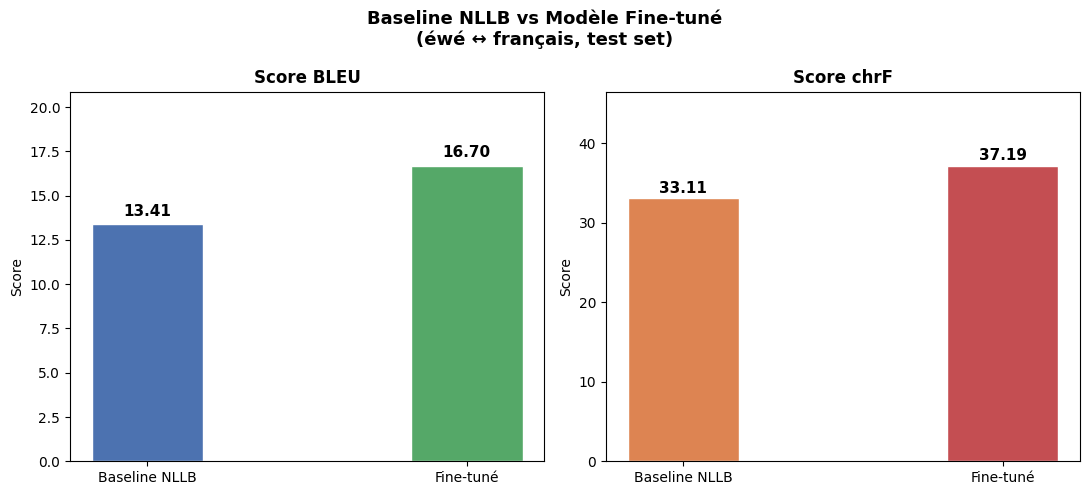

✅ Graphique sauvegardé : outputs/comparison_baseline_finetuned.png


In [ ]:
# ── 4.3 Graphique de comparaison ─────────────────────────────────────────────
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Lecture des résultats sauvegardés par 4.2
with open("outputs/comparison_results.json") as f:
    comparison = json.load(f)

results_baseline  = comparison['baseline']
results_finetuned = comparison['finetuned']

labels      = ['Baseline NLLB', 'Fine-tuné']
bleu_scores = [results_baseline['bleu'], results_finetuned['bleu']]
chrf_scores = [results_baseline['chrf'], results_finetuned['chrf']]

x     = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# -- BLEU --
bars_bleu = axes[0].bar(x, bleu_scores, width,
                        color=['#4C72B0', '#55A868'], edgecolor='white')
axes[0].set_title('Score BLEU', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, max(bleu_scores) * 1.25)
for bar in bars_bleu:
    axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
                 f'{bar.get_height():.2f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

# -- chrF --
bars_chrf = axes[1].bar(x, chrf_scores, width,
                        color=['#DD8452', '#C44E52'], edgecolor='white')
axes[1].set_title('Score chrF', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, max(chrf_scores) * 1.25)
for bar in bars_chrf:
    axes[1].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
                 f'{bar.get_height():.2f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.suptitle('Baseline NLLB vs Modèle Fine-tuné\n(éwé ↔ français, test set)',
             fontweight='bold', fontsize=13)
plt.tight_layout()

chart_path = Path("outputs/comparison_baseline_finetuned.png")
plt.savefig(chart_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"✅ Graphique sauvegardé : {chart_path}")

---
## Section 5 — Error Analysis

Identification et analyse des traductions les plus mauvaises pour comprendre
les limites du modèle et les axes d'amélioration.

In [8]:
# ── 5.1 Génération des traductions sur le test set complet ──────────────────
import os
import gc
import torch
import pandas as pd
from pathlib import Path
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from tqdm import tqdm
import sacrebleu

gc.collect()
torch.cuda.empty_cache()

HF_TOKEN       = os.environ.get("HF_TOKEN_READ")
FINETUNED_PATH = "outputs/final_model"
OUTPUT_DIR     = Path("outputs/error_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
predictions_path = OUTPUT_DIR / "test_predictions.csv"

# ── Vérification : prédictions déjà générées ? ───────────────────────────────
if predictions_path.exists():
    df_results = pd.read_csv(predictions_path)
    print(f"✅ Prédictions déjà disponibles ({len(df_results):,} lignes) — génération ignorée.")
    SKIP_GENERATION = True
else:
    SKIP_GENERATION = False

if not SKIP_GENERATION:
    print("Chargement de GbeTo ...")
    tokenizer = AutoTokenizer.from_pretrained(
        FINETUNED_PATH, cache_dir="hf_cache", token=HF_TOKEN
    )
    model = AutoModelForSeq2SeqLM.from_pretrained(
        FINETUNED_PATH,
        cache_dir="hf_cache",
        token=HF_TOKEN,
        dtype=torch.float16,
        device_map="cuda"
    )
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.eval()
    print(f"  Chargé sur : {device.upper()}")

    df_test  = pd.read_csv('data/processed/test.csv')
    lang_map = {
        'ewe-fra': ('ewe_Latn', 'fra_Latn'),
        'fra-ewe': ('fra_Latn', 'ewe_Latn'),
    }
    print(f"  Test set : {len(df_test):,} paires")

    # ── Génération par batch — écriture incrémentale pour éviter l'OOM ───────
    BATCH_SIZE     = 32
    header_written = False
    batch          = []

    with open(predictions_path, 'w', encoding='utf-8') as f:
        for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Génération"):
            src_lang, tgt_lang = lang_map.get(row['direction'], ('ewe_Latn', 'fra_Latn'))
            tokenizer.src_lang = src_lang
            inputs = tokenizer(
                row['source'], return_tensors='pt', max_length=128, truncation=True
            ).to(device)
            forced_bos = tokenizer.convert_tokens_to_ids(tgt_lang)

            with torch.no_grad():
                out = model.generate(
                    **inputs, forced_bos_token_id=forced_bos,
                    num_beams=4, max_new_tokens=128
                )
            hypothesis = tokenizer.decode(out[0], skip_special_tokens=True).strip()

            batch.append({
                'source':     row['source'],
                'reference':  row['target'],
                'hypothesis': hypothesis,
                'direction':  row['direction'],
                'origin':     row.get('origin', ''),
            })

            if len(batch) >= BATCH_SIZE:
                pd.DataFrame(batch).to_csv(f, index=False, header=not header_written)
                header_written = True
                batch = []
                torch.cuda.empty_cache()

        # Dernier batch
        if batch:
            pd.DataFrame(batch).to_csv(f, index=False, header=not header_written)

    print(f"\n✅ {len(df_test):,} prédictions sauvegardées : {predictions_path}")

    # ── Libération mémoire ────────────────────────────────────────────────────
    del model
    gc.collect()
    torch.cuda.empty_cache()
    print("  Mémoire GPU libérée.")

    df_results = pd.read_csv(predictions_path)

# ── Calcul bleu_sent si colonne absente ──────────────────────────────────────
# Note : le score BLEU sentence-level (bleu_sent) est calculé avec le tokenizer
# '13a' (Moses) et non 'flores101', pour des raisons de contraintes mémoire sur
# Colab (flores101 est trop lourd pour 3 484 appels séquentiels).
# Cette colonne sert uniquement au ranking des pires traductions (cellules 5.2
# et 5.3) — les métriques officielles du README utilisent bien flores101 via
# compute_bleu() de src/evaluate/metrics.py.

if 'bleu_sent' not in df_results.columns:
    print("  Calcul des scores BLEU sentence-level ...")
    bleu_scores = []
    for i, (_, r) in enumerate(tqdm(df_results.iterrows(), total=len(df_results), desc="BLEU sentence")):
        score = sacrebleu.sentence_bleu(
            r['hypothesis'], [r['reference']], tokenize='13a'
        ).score
        bleu_scores.append(round(score, 2))

        # Libérer sacrebleu toutes les 100 itérations
        if i % 100 == 0 and i > 0:
            gc.collect()

    df_results['bleu_sent'] = bleu_scores
    df_results.to_csv(predictions_path, index=False, encoding='utf-8')
    print("  Scores ajoutés et sauvegardés.")
else:
    print("  Scores BLEU sentence-level déjà présents — calcul ignoré.")

# ── Métriques globales ───────────────────────────────────────────────────────
from src.evaluate.metrics import compute_bleu, compute_chrf

print("\n" + "=" * 50)
print("MÉTRIQUES — TEST SET COMPLET")
print("=" * 50)
for direction in ['ewe-fra', 'fra-ewe', None]:
    if direction:
        subset = df_results[df_results['direction'] == direction]
        label  = direction
    else:
        subset = df_results
        label  = 'global'
    bleu = compute_bleu(subset['hypothesis'].tolist(), subset['reference'].tolist())
    chrf = compute_chrf(subset['hypothesis'].tolist(), subset['reference'].tolist())
    print(f"  {label:<12} — BLEU : {bleu:.2f}  |  chrF : {chrf:.2f}  |  n={len(subset):,}")

✅ Prédictions déjà disponibles (3,484 lignes) — génération ignorée.
  Calcul des scores BLEU sentence-level ...


BLEU sentence: 100%|██████████| 3484/3484 [00:20<00:00, 165.92it/s]


  Scores ajoutés et sauvegardés.

MÉTRIQUES — TEST SET COMPLET
  ewe-fra      — BLEU : 16.05  |  chrF : 39.47  |  n=1,739
  fra-ewe      — BLEU : 19.18  |  chrF : 38.27  |  n=1,745
  global       — BLEU : 17.73  |  chrF : 38.97  |  n=3,484


In [9]:
# ── 5.2 Les 20 pires traductions (score BLEU individuel le plus bas) ─────────
from pathlib import Path

# df_results chargé depuis fichier si cellule 5.1 non exécutée
if 'df_results' not in dir():
    import pandas as pd
    df_results = pd.read_csv('outputs/error_analysis/test_predictions.csv')

df_worst = df_results.nsmallest(20, 'bleu_sent')

print("=" * 75)
print("20 PIRES TRADUCTIONS (BLEU sentence-level)")
print("=" * 75)

for i, (_, row) in enumerate(df_worst.iterrows(), 1):
    print(f"\n[{i:02d}] Direction : {row['direction']}  |  BLEU : {row['bleu_sent']:.1f}  |  Origine : {row.get('origin', '')}")
    print(f"     Source     : {str(row['source'])[:100]}")
    print(f"     Référence  : {str(row['reference'])[:100]}")
    print(f"     Hypothèse  : {str(row['hypothesis'])[:100]}")

worst_path = Path("outputs/error_analysis/worst_20_predictions.csv")
df_worst.to_csv(worst_path, index=False, encoding='utf-8')
print(f"\n✅ Sauvegardé : {worst_path}")

20 PIRES TRADUCTIONS (BLEU sentence-level)

[01] Direction : ewe-fra  |  BLEU : 0.0  |  Origine : afrolingu
     Source     : nyemate ŋu agblɔ nye seselelãme o
     Référence  : « Essayer de mettre des mots sur ce que je ressens maintenant serait une tâche impossible
     Hypothèse  : Je ne peux pas exprimer mes sentiments,

[02] Direction : ewe-fra  |  BLEU : 0.0  |  Origine : afrolingu
     Source     : wowɔa ƒoƒose siawo le seɖoɖo siawo nue:
     Référence  : qui nous respectera et nous menera vers cet horizon longtemps promis.
     Hypothèse  : Les discours sont organisés selon les règles suivantes :

[03] Direction : fra-ewe  |  BLEU : 0.0  |  Origine : afrolingu
     Source     : Elle allait se faire des idées sur sa personne
     Référence  : Adze tame aɖe bubu tso eŋutie
     Hypothèse  : Eyi ɖaɖe susu aɖewo le eɖokui ŋu.

[04] Direction : ewe-fra  |  BLEU : 0.0  |  Origine : mafand
     Source     : Le nuwuwua, tu ɖi ɖe nenem mea dzi.
     Référence  : L'homme a finalement été

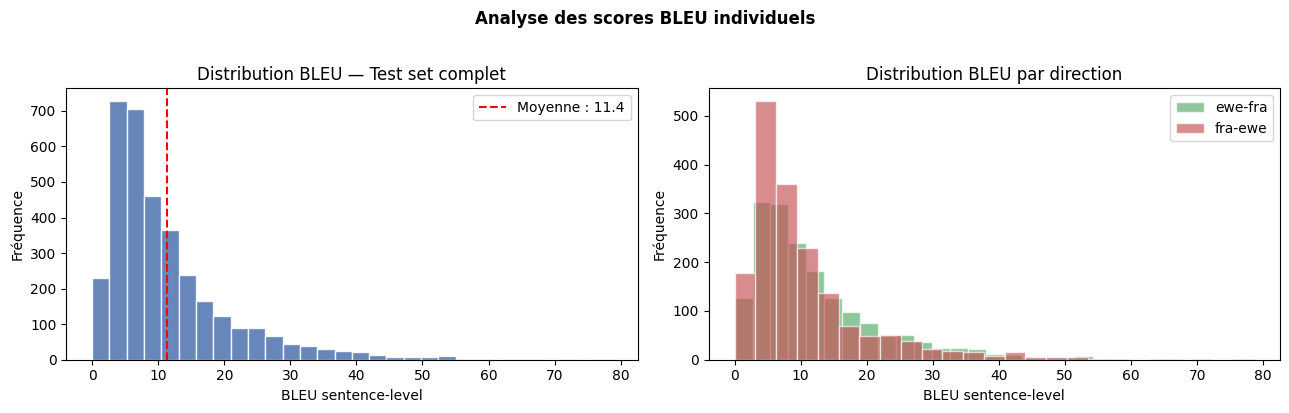


Statistiques par direction :
            mean  median   std
direction                     
ewe-fra    12.05    9.13  9.66
fra-ewe    10.67    7.45  9.66

✅ Graphique sauvegardé : outputs/error_analysis/bleu_distribution.png


In [10]:
# ── 5.3 Distribution des scores BLEU individuels ────────────────────────────
import matplotlib.pyplot as plt
from pathlib import Path

# df_results chargé depuis fichier si cellule 5.1 non exécutée
if 'df_results' not in dir():
    import pandas as pd
    df_results = pd.read_csv('outputs/error_analysis/test_predictions.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution globale
axes[0].hist(df_results['bleu_sent'], bins=30,
             color='#4C72B0', alpha=0.85, edgecolor='white')
axes[0].axvline(df_results['bleu_sent'].mean(), color='red',
                linestyle='--', label=f"Moyenne : {df_results['bleu_sent'].mean():.1f}")
axes[0].set_xlabel('BLEU sentence-level')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution BLEU — Test set complet')
axes[0].legend()

# Par direction
for direction, color in [('ewe-fra', '#55A868'), ('fra-ewe', '#C44E52')]:
    subset = df_results[df_results['direction'] == direction]['bleu_sent']
    axes[1].hist(subset, bins=25, alpha=0.65, label=direction,
                 color=color, edgecolor='white')

axes[1].set_xlabel('BLEU sentence-level')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution BLEU par direction')
axes[1].legend()

plt.suptitle('Analyse des scores BLEU individuels', fontweight='bold', y=1.02)
plt.tight_layout()

chart_path = Path("outputs/error_analysis/bleu_distribution.png")
plt.savefig(chart_path, bbox_inches='tight', dpi=150)
plt.show()

print("\nStatistiques par direction :")
print(df_results.groupby('direction')['bleu_sent'].agg(['mean', 'median', 'std']).round(2))
print(f"\n✅ Graphique sauvegardé : {chart_path}")

---
## Section 6 — Démonstration interactive

In [11]:
# ── 6.1 Traduction interactive ───────────────────────────────────────────────
import os
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

FINETUNED_PATH = "outputs/final_model"
HF_TOKEN       = os.environ.get("HF_TOKEN_READ")

# Réutilise le modèle de 5.1 s'il est encore en mémoire
if 'model' not in dir() or model is None:
    print("Chargement du modèle fine-tuné ...")
    tokenizer = AutoTokenizer.from_pretrained(
        FINETUNED_PATH, cache_dir="hf_cache", token=HF_TOKEN
    )
    model  = AutoModelForSeq2SeqLM.from_pretrained(
        FINETUNED_PATH, cache_dir="hf_cache", token=HF_TOKEN
    )
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model  = model.to(device).eval()
    print(f"  Chargé sur : {device.upper()}")

def translate(text: str, direction: str = 'fra-ewe') -> str:
    lang_map = {
        'ewe-fra': ('ewe_Latn', 'fra_Latn'),
        'fra-ewe': ('fra_Latn', 'ewe_Latn'),
    }
    src_lang, tgt_lang = lang_map[direction]
    tokenizer.src_lang = src_lang
    inputs = tokenizer(
        text, return_tensors='pt', max_length=128, truncation=True
    ).to(device)
    forced_bos = tokenizer.convert_tokens_to_ids(tgt_lang)
    with torch.no_grad():
        out = model.generate(
            **inputs, forced_bos_token_id=forced_bos,
            num_beams=4, max_length=256
        )
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

# ── TEXTE DE DEMO ──────────────────────────────────────────────────────────────
TEXTE     = "L'eau potable est un droit fondamental pour toute personne."
DIRECTION = "fra-ewe"   # 'fra-ewe' ou 'ewe-fra'
# ─────────────────────────────────────────────────────────────────────────────

traduction = translate(TEXTE, DIRECTION)

print(f"Direction  : {DIRECTION}")
print(f"Source     : {TEXTE}")
print(f"Traduction : {traduction}")

Chargement du modèle fine-tuné ...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Chargé sur : CUDA
Direction  : fra-ewe
Source     : L'eau potable est un droit fondamental pour toute personne.
Traduction : Tsi nyui nye ame sia ame ƒe dzena.


In [ ]:
# ── 6.2 Lancement de l'interface Gradio ──────────────────────────────────────

!python app.py

2026-03-13 16:22:57 | INFO | __main__ | =======================================================
2026-03-13 16:22:57 | INFO | __main__ | Démarrage — Traducteur Éwé ↔ Français
2026-03-13 16:22:57 | INFO | __main__ | =======================================================
2026-03-13 16:22:57 | INFO | __main__ | Chargement du modèle fine-tuné : outputs/final_model
Loading weights: 100% 512/512 [00:00<00:00, 545.22it/s, Materializing param=model.shared.weight]
The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The